In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images :", X_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


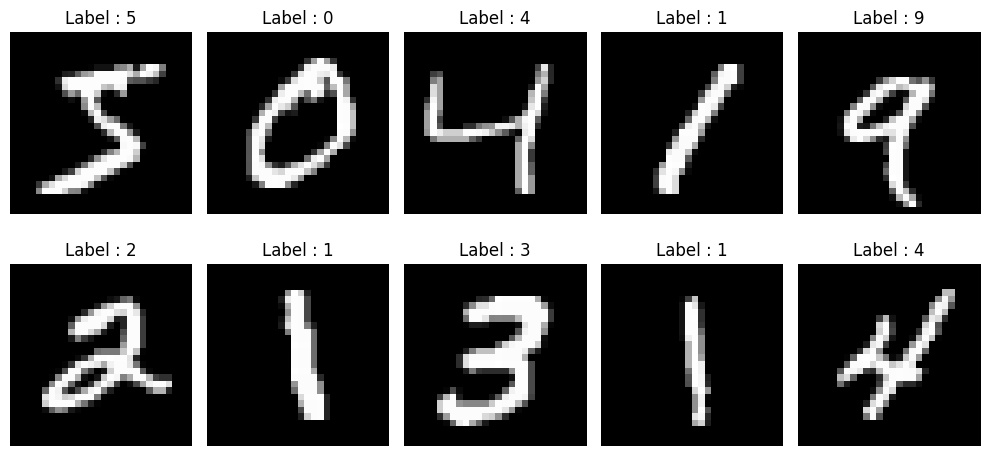

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title("Label : {}".format(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalization Completed")

Normalization Completed


In [ ]:
X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("One-Hot Encoding Completed")
print("Training Labels Shape :", y_train.shape)
print("Testing Labels Shape :", y_test.shape)

One-Hot Encoding Completed
Training Labels Shape : (60000, 10)
Testing Labels Shape : (10000, 10)


In [ ]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.9257 - loss: 0.2438 - val_accuracy: 0.9797 - val_loss: 0.0658
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 101s 46ms/step - accuracy: 0.9738 - loss: 0.0898 - val_accuracy: 0.9838 - val_loss: 0.0523
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 36ms/step - accuracy: 0.9801 - loss: 0.0676 - val_accuracy: 0.9882 - val_loss: 0.0415
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 77s 33ms/step - accuracy: 0.9843 - loss: 0.0518 - val_accuracy: 0.9900 - val_loss: 0.0352
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9859 - loss: 0.0464 - val_accuracy: 0.9896 - val_loss: 0.0382
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9880 - loss: 0.0375 - val_accuracy: 0.9911 - val_loss: 0.0350
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9900 - loss: 0.0311 - val_accuracy: 0.9898 - val_loss: 0.0356
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9908 

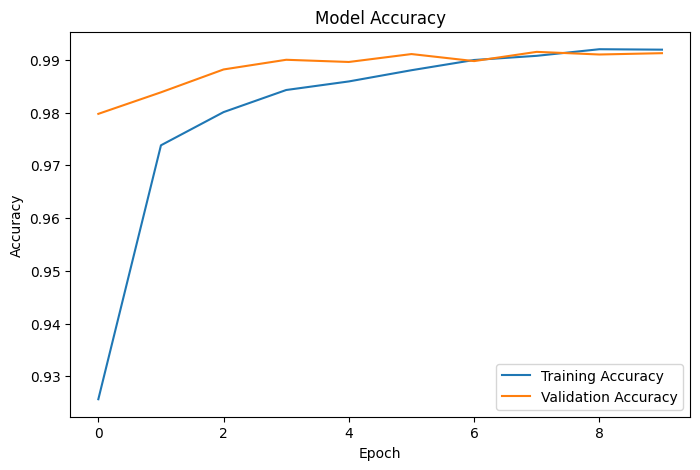

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

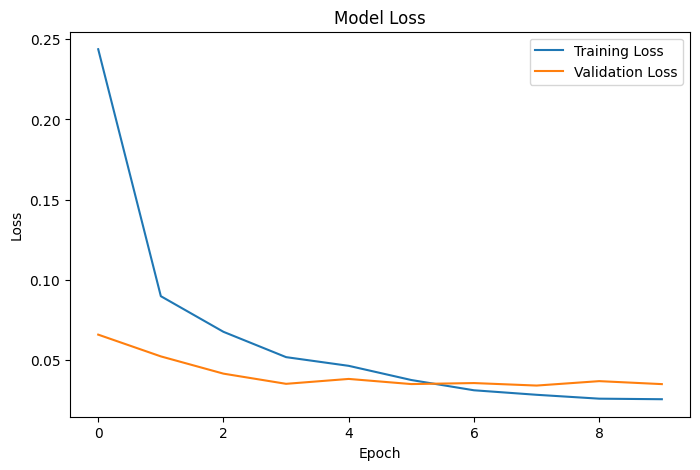

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9915 - loss: 0.0277
Test Loss : 0.02774754911661148
Test Accuracy : 0.9915000200271606


In [ ]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


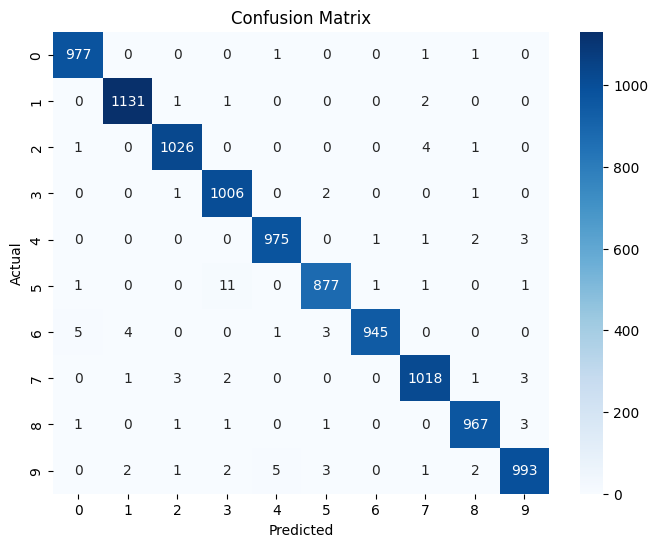

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



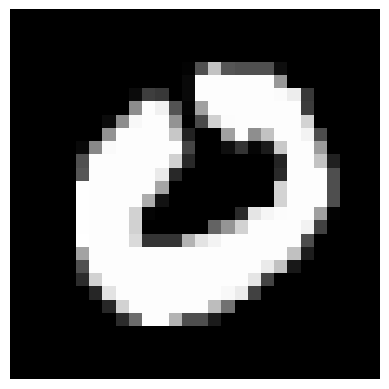

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Predicted Digit : 3
Actual Digit : 0


In [ ]:
plt.imshow(X_test[25].reshape(28,28), cmap="gray")
plt.axis("off")
plt.show()

prediction = model.predict(X_test[25].reshape(1,28,28,1))

digit = np.argmax(prediction)

print("Predicted Digit :", digit)
print("Actual Digit :", y_true[25])

In [ ]:
model.save("handwritten_character_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
print("="*60)
print("      HANDWRITTEN CHARACTER RECOGNITION")
print("="*60)

print("Dataset : MNIST")
print("Model : Convolutional Neural Network (CNN)")
print("Test Accuracy :", round(accuracy*100,2), "%")

print("\nProject Completed Successfully!")

print("="*60)


      HANDWRITTEN CHARACTER RECOGNITION
Dataset : MNIST
Model : Convolutional Neural Network (CNN)
Test Accuracy : 99.15 %

Project Completed Successfully!
